In [45]:
# 1. Clone the repo
!git clone https://github.com/fastai/course-v3.git

# 2. Move the exp folder to your current directory
!mv course-v3/nbs/dl2/exp .

# 3. Clean up the rest (optional)
!rm -rf course-v3

Cloning into 'course-v3'...
remote: Enumerating objects: 5909, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 5909 (delta 9), reused 1 (delta 1), pack-reused 5893 (from 1)
Receiving objects: 100% (5909/5909), 263.04 MiB | 26.78 MiB/s, done.
Resolving deltas: 100% (3259/3259), done.
Updating files: 100% (887/887), done.
mv: cannot move 'course-v3/nbs/dl2/exp' to './exp': Directory not empty


In [46]:
from exp.nb_04 import *

In [47]:
import os
import urllib.request

In [48]:
MNIST_URL = 'https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz'

# Set path to the local Colab content folder
path = Path('mnist.pkl.gz')

if not path.exists():
    print("Downloading MNIST pkl.gz...")
    urllib.request.urlretrieve(MNIST_URL, path)

print(f"File downloaded to: {path.absolute()}")

File downloaded to: /content/mnist.pkl.gz


In [49]:
with gzip.open(path, 'rb') as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

In [50]:
def get_data(path):
    # path = datasets.download_data(MNIST_URL, ext='.gz')
    with gzip.open(path, 'rb') as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')
    return map(tensor, (x_train,y_train,x_valid,y_valid))

def normalize(x, m, s): return (x-m)/s

## Initial setup

In [51]:
x_train,y_train,x_valid,y_valid = get_data(path)
train_ds,valid_ds = Dataset(x_train, y_train),Dataset(x_valid, y_valid)
nh,bs = 50,512
c = y_train.max().item()+1
loss_func = F.cross_entropy

In [52]:
data = DataBunch(*get_dls(train_ds, valid_ds, bs), c)

In [53]:
def create_learner(model_func, loss_func, data):
    return Learner(*model_func(data), loss_func, data)

defaults to lr of 0.5:

In [54]:
learn = create_learner(get_model, loss_func, data)
run = Runner([AvgStatsCallback([accuracy])])

run.fit(3, learn)

train: [0.682883515625, tensor(0.7995)]
valid: [0.295249755859375, tensor(0.9179)]
train: [0.29957548828125, tensor(0.9124)]
valid: [0.23889609375, tensor(0.9337)]
train: [0.23777623046875, tensor(0.9308)]
valid: [0.21433583984375, tensor(0.9376)]


In [55]:
learn = create_learner(partial(get_model, lr=0.3), loss_func, data)
run = Runner([AvgStatsCallback([accuracy])])

run.fit(3, learn)

train: [0.75336578125, tensor(0.8035)]
valid: [0.3500693603515625, tensor(0.9051)]
train: [0.3468841796875, tensor(0.8990)]
valid: [0.2872005615234375, tensor(0.9187)]
train: [0.2972144921875, tensor(0.9147)]
valid: [0.2655262939453125, tensor(0.9254)]


In [56]:
def get_model_func(lr=0.5): return partial(get_model, lr=lr)

## Annealing
We define two new callbacks:
- the Recorder to save track of the loss and our scheduled learning rate
- ParamScheduler that can schedule any hyperparameter as long as it's registered in the state_dict of the optimizer.

In [57]:
class Recorder(Callback):
    def begin_fit(self): self.lrs,self.losses = [],[]

    def after_batch(self):
        if not self.in_train: return
        self.lrs.append(self.opt.param_groups[-1]['lr'])
        self.losses.append(self.loss.detach().cpu())

    def plot_lr  (self): plt.plot(self.lrs)
    def plot_loss(self): plt.plot(self.losses)

class ParamScheduler(Callback):
    _order=1
    def __init__(self, pname, sched_func): self.pname,self.sched_func = pname,sched_func

    def set_param(self):
        for pg in self.opt.param_groups:
            pg[self.pname] = self.sched_func(self.n_epochs/self.epochs)

    def begin_batch(self):
        if self.in_train: self.set_param()

we're going to create a callback that's going to do hyperparameter scheduling; `ParamScheduler` - pass it a function & parameter to schedule (`lr`)
- the result of `sched_func` will be used to set the hyperparemeter (`lr`)
- we're just going to do lr as the hyperparameter
- however people have pointed out that you can/should schedule everything; dropout amount, kind of data augmentation you do, weight decay, lr, momentum, etc
  - makes sense; as you train a model if kind of goes through different "phases" - the loss landscaped of NNs look very different at the start/middle/end, so it's very unlikely that you'd want the same hyperparameters throughout

Let's start with a simple linear schedule going from start to end.  
It returns a function that takes a `pos` argument (going from 0 to 1) such that this function goes from start (at `pos=0`) to end (at `pos=1`) in a linear fashion.

In [58]:
def sched_lin(start, end):
    def _inner(start, end, pos): return start + pos*(end-start)
    return partial(_inner, start, end)

We can refactor this with a decorator.

In [59]:
def annealer(f):
    def _inner(start, end): return partial(f, start, end)
    return _inner

@annealer
def sched_lin(start, end, pos): return start + pos*(end-start)

a decorator is a function that returns a function  
If Python sees the name of a fn with an `@` sign before it (eg: `@annealer`), then it takes the below fn and passes it to the decorator fn and replaces the definition of the bottom fn (eg: `sched_lin`) with whatever the decorator fn returns.



In [60]:
# shift-tab works too, in Jupyter!
# sched_lin()

scheduler that starts at lr=1, ends at lr=2

In [61]:
f = sched_lin(1,2)
f(0.3)

1.3

And here are other scheduler functions:

now we can just go ahead and define all of our different schedulers by passing it start, end, pos

In [62]:
@annealer
def sched_cos(start, end, pos): return start + (1 + math.cos(math.pi*(1-pos))) * (end-start) / 2
@annealer
def sched_no(start, end, pos):  return start
@annealer
def sched_exp(start, end, pos): return start * (end/start) ** pos

def cos_1cycle_anneal(start, high, end):
    return [sched_cos(start, high), sched_cos(high, end)]

#This monkey-patch is there to be able to plot tensors
torch.Tensor.ndim = property(lambda x: len(x.shape))

you can't plot pytorch tensors - because tensors don't have an `ndim` attribute, which tells matplotlib how many dims there are

`torch.Tensor.ndim = property(lambda x: len(x.shape))`
- inserts into a pytorch tensor a new `property` called `ndim`

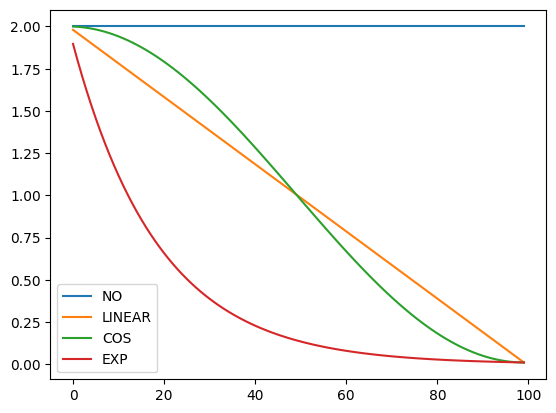

In [63]:
annealings = "NO LINEAR COS EXP".split()

a = torch.arange(0, 100)
p = torch.linspace(0.01,1,100)

fns = [sched_no, sched_lin, sched_cos, sched_exp]
for fn, t in zip(fns, annealings):
    f = fn(2, 1e-2)
    plt.plot(a, [f(o) for o in p], label=t)
plt.legend();

most of the time nowdays you want some kind of warmup / cooldown, or multiple cooldowns (SGDR), so we need to be able to paste some of these schedulers together

In practice, we'll often want to combine different schedulers, the following function does that: it uses scheds[i] for pcts[i] of the training.

In [64]:
def combine_scheds(pcts, scheds):
    assert sum(pcts) == 1.
    pcts = tensor([0] + listify(pcts))
    assert torch.all(pcts >= 0)
    pcts = torch.cumsum(pcts, 0)
    def _inner(pos):
        idx = (pos >= pcts).nonzero().max()
        if idx == 2: idx = 1
        actual_pos = (pos-pcts[idx]) / (pcts[idx+1]-pcts[idx])
        return scheds[idx](actual_pos)
    return _inner

Here is an example: use 30% of the budget to go from 0.3 to 0.6 following a cosine, then the last 70% of the budget to go from 0.6 to 0.2, still following a cosine.

In [65]:
sched = combine_scheds([0.3, 0.7], [sched_cos(0.3, 0.6), sched_cos(0.6, 0.2)])

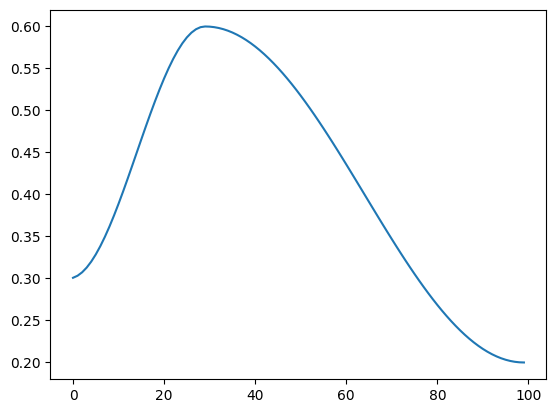

In [66]:
plt.plot(a, [sched(o) for o in p])

need to train at a high lr for a long time, but then also need to fine-tune at a very low lr for a long time

We can use it for training quite easily...

In [67]:
cbfs = [Recorder,
        partial(AvgStatsCallback,accuracy),
        partial(ParamScheduler, 'lr', sched)]

In [68]:
learn = create_learner(get_model_func(0.3), loss_func, data)
run = Runner(cb_funcs=cbfs)

In [69]:
run.fit(3, learn)

train: [0.803421953125, tensor(0.7771)]
valid: [0.32036416015625, tensor(0.9085)]
train: [0.30139625, tensor(0.9122)]
valid: [0.237532421875, tensor(0.9332)]
train: [0.23554279296875, tensor(0.9329)]
valid: [0.208648388671875, tensor(0.9433)]


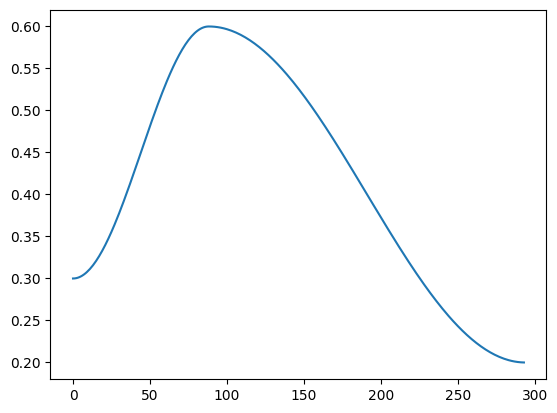

In [70]:
run.recorder.plot_lr()

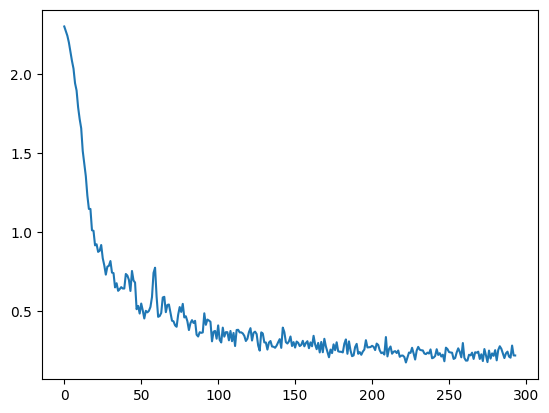

In [71]:
  run.recorder.plot_loss()